In [ ]:
#Q1
import torch
import torch.nn as nn
import math

def conv_out_size(Hin,Win,K,S,P):
    Hout=math.floor((Hin+2*P-K)/S)+1
    Wout=math.floor((Win+2*P-K)/S)+1
    return Hout,Wout

x=torch.randn(6,6)
x=x.unsqueeze(dim=0)
print(x.shape)
x=x.unsqueeze(dim=0)
print(x.shape)

K=3
oc=8
weight=torch.randn(8,1,3,3)
bias=torch.randn(8)

print("\nVary stride, padding=0")
for S in [1,2,3]:
    conv=nn.Conv2d(in_channels=1,
                   out_channels=oc,
                   kernel_size=K,
                   stride=S,
                   padding=0)
    y=conv(x)
    Hf,Wf=conv_out_size(6,6,K,S,0)
    print(f"Stride: {S}, Pytorch out={tuple(y.shape)}, Using function formula: (1,{oc},{Hf},{Wf})")

print("\nVary padding, stride=1")
for P in [0,1,2]:
    conv=nn.Conv2d(in_channels=1,
                   out_channels=oc,
                   kernel_size=K,
                   stride=1,
                   padding=P)
    y=conv(x)
    Hf,Wf=conv_out_size(6,6,K,1,P)
    print(f"Padding: {P}, Pytorch out={tuple(y.shape)}, Using function formula: (1,{oc},{Hf},{Wf})")

total_params=sum(p.numel() for p in conv.parameters() if p.requires_grad)
print("\nTotal Conv2d Parameters: ",total_params)

for name,p in conv.named_parameters():
    print(name,p.shape,"-->",p.numel())

#Num of parms in weights=out_channels*ip_channels*kernelsizeH*kernel_sizeW, bias=out_channels, Total=ws+bs

torch.Size([1, 6, 6])
torch.Size([1, 1, 6, 6])

Vary stride, padding=0
Stride: 1, Pytorch out=(1, 8, 4, 4), Using function formula: (1,8,4,4)
Stride: 2, Pytorch out=(1, 8, 2, 2), Using function formula: (1,8,2,2)
Stride: 3, Pytorch out=(1, 8, 2, 2), Using function formula: (1,8,2,2)

Vary padding, stride=1
Padding: 0, Pytorch out=(1, 8, 4, 4), Using function formula: (1,8,4,4)
Padding: 1, Pytorch out=(1, 8, 6, 6), Using function formula: (1,8,6,6)
Padding: 2, Pytorch out=(1, 8, 8, 8), Using function formula: (1,8,8,8)

Total Conv2d Parameters:  80
weight torch.Size([8, 1, 3, 3]) --> 72
bias torch.Size([8]) --> 8


In [16]:
#Q2
import torch
import torch.nn as nn
import math

def conv_out_size(Hin,Win,K,S,P):
    Hout=math.floor((Hin+2*P-K)/S)+1
    Wout=math.floor((Win+2*P-K)/S)+1
    return Hout,Wout

x=torch.randn(28,28)
x=x.unsqueeze(dim=0)#(1,28,28)
print(x.shape)
x=x.unsqueeze(dim=0)#(1,1,28,28)
print(x.shape)

K=3
oc=8
weight=torch.randn(8,3,3,3)
bias=torch.randn(8)

x=x.repeat(1,3,1,1) #(1,3,28,28)

print("\nVary stride, padding=0")
for S in [1,2,3]:
    conv=nn.Conv2d(in_channels=3,
                   out_channels=oc,
                   kernel_size=K,
                   stride=S,
                   padding=0)
    y=conv(x)
    #print(conv.weight)
    Hf,Wf=conv_out_size(28,28,K,S,0)
    print(f"Stride: {S} , Pytorch out={tuple(y.shape)} , Using function formula: (1,{oc},{Hf},{Wf})")

print("\nVary padding, stride =1")
for P in [0,1,2]:
    conv=nn.Conv2d(in_channels=3,
                   out_channels=oc,
                   kernel_size=K,
                   stride=1,
                   padding=P)
    y=conv(x)
    Hf,Wf=conv_out_size(28,28,K,1,P)
    print(f"Padding: {P} , Pytorch out={tuple(y.shape)} , Using function formula: (1,{oc},{Hf},{Wf})")

total_params=sum(p.numel() for p in conv.parameters() if p.requires_grad)
print("\nTotal Conv2d parameters:",total_params)

for name,p in conv.named_parameters():
    print(name,p.shape,"-->",p.numel())


torch.Size([1, 28, 28])
torch.Size([1, 1, 28, 28])

Vary stride, padding=0
Stride: 1 , Pytorch out=(1, 8, 26, 26) , Using function formula: (1,8,26,26)
Stride: 2 , Pytorch out=(1, 8, 13, 13) , Using function formula: (1,8,13,13)
Stride: 3 , Pytorch out=(1, 8, 9, 9) , Using function formula: (1,8,9,9)

Vary padding, stride =1
Padding: 0 , Pytorch out=(1, 8, 26, 26) , Using function formula: (1,8,26,26)
Padding: 1 , Pytorch out=(1, 8, 28, 28) , Using function formula: (1,8,28,28)
Padding: 2 , Pytorch out=(1, 8, 30, 30) , Using function formula: (1,8,30,30)

Total Conv2d parameters: 224
weight torch.Size([8, 3, 3, 3]) --> 216
bias torch.Size([8]) --> 8


In [2]:
#Using functional 2d-6X6, 1 ip channel

import torch
import torch.nn as nn
import math

def conv_out_size(Hin,Win,K,S,P):
    Hout=math.floor((Hin+2*P-K)/S)+1
    Wout=math.floor((Win+2*P-K)/S)+1
    return Hout,Wout

x=torch.randn(6,6)
x=x.unsqueeze(dim=0)#(1,28,28)
print(x.shape)
x=x.unsqueeze(dim=0)#(1,1,28,28)
print(x.shape)

K=3
oc=8

weight=torch.randn(8,1,3,3)
bias=torch.randn(8)

print("\nVary Stride, padding=0")
for S in [1,2,3]:
    conv=nn.functional.conv2d(input=x,
                              weight=weight,
                              bias=bias,
                              stride=S,
                              padding=0)
    Hf,Wf=conv_out_size(6,6,K,S,0)
    print(f"Stride: {S}, Pytorch out: {tuple(conv.shape)}, Using formula function: (1,{oc},{Hf},{Wf})")

print("\nVary Padding, Stride=1")
for P in [0,1,2]:
    conv=nn.functional.conv2d(input=x, #when functonal API used, w,b must be passed as input n it return a output tensor
                              weight=weight,
                              bias=bias,
                              stride=1,
                              padding=P)
    Hf,Wf=conv_out_size(6,6,K,1,P)
    print(f"Padding: {P}, Pytorch out: {tuple(conv.shape)}, Using formula function: (1,{oc},{Hf},{Wf})")

total_params=sum(p.numel() for p in [weight,bias])
print("\nTotal conv2d parameters: ",total_params)


torch.Size([1, 6, 6])
torch.Size([1, 1, 6, 6])

Vary Stride, padding=0
Stride: 1, Pytorch out: (1, 8, 4, 4), Using formula function: (1,8,4,4)
Stride: 2, Pytorch out: (1, 8, 2, 2), Using formula function: (1,8,2,2)
Stride: 3, Pytorch out: (1, 8, 2, 2), Using formula function: (1,8,2,2)

Vary Padding, Stride=1
Padding: 0, Pytorch out: (1, 8, 4, 4), Using formula function: (1,8,4,4)
Padding: 1, Pytorch out: (1, 8, 6, 6), Using formula function: (1,8,6,6)
Padding: 2, Pytorch out: (1, 8, 8, 8), Using formula function: (1,8,8,8)

Total conv2d parameters:  80


In [ ]:
#Using functional 2d-28 X 28, 3 ip channel

import torch
import torch.nn as nn
import math

def conv_out_size(Hin,Win,K,S,P):
    Hout=math.floor((Hin+2*P-K)/S)+1
    Wout=math.floor((Win+2*P-K)/S)+1
    return Hout,Wout

x=torch.randn(28,28)
x=x.unsqueeze(dim=0)#(1,28,28)
print(x.shape)
x=x.unsqueeze(dim=0)#(1,1,28,28)
print(x.shape)

K=3
oc=8

weight=torch.randn(8,3,3,3)
bias=torch.randn(8)

x=x.repeat(1,3,1,1)
print(x.shape)

print("\nVary Stride, padding=0")
for S in [1,2,3]:
    conv=nn.functional.conv2d(input=x,
                              weight=weight,
                              bias=bias,
                              stride=S,
                              padding=0)
    Hf,Wf=conv_out_size(28,28,K,S,0)
    print(f"Stride: {S}, Pytorch out: {tuple(conv.shape)}, Using formula function: (1,{oc},{Hf},{Wf})")

print("\nVary Padding, Stride=1")
for P in [0,1,2]:
    conv=nn.functional.conv2d(input=x, #when functonal API used, w,b must be passed as input n it return a output tensor
                              weight=weight,
                              bias=bias,
                              stride=1,
                              padding=P)
    Hf,Wf=conv_out_size(28,28,K,1,P)
    print(f"Stride: {S}, Pytorch out: {tuple(conv.shape)}, Using formula function: (1,{oc},{Hf},{Wf})")

total_params=sum(p.numel() for p in [weight,bias])
print("\nTotal conv2d parameters: ",total_params)


torch.Size([1, 28, 28])
torch.Size([1, 1, 28, 28])
torch.Size([1, 3, 28, 28])

Vary Stride, padding=0
Stride: 1, Pytorch out: (1, 8, 26, 26), Using formula function: (1,8,26,26)
Stride: 2, Pytorch out: (1, 8, 13, 13), Using formula function: (1,8,13,13)
Stride: 3, Pytorch out: (1, 8, 9, 9), Using formula function: (1,8,9,9)

Vary Padding, Stride=1
Stride: 3, Pytorch out: (1, 8, 26, 26), Using formula function: (1,8,26,26)
Stride: 3, Pytorch out: (1, 8, 28, 28), Using formula function: (1,8,28,28)
Stride: 3, Pytorch out: (1, 8, 30, 30), Using formula function: (1,8,30,30)

Total conv2d parameters:  224


Total Trainable Parameters:  149798
Epoch: 1, Loss: 0.2941
Epoch: 2, Loss: 0.0923
Epoch: 3, Loss: 0.0652
Epoch: 4, Loss: 0.0538
Epoch: 5, Loss: 0.0420


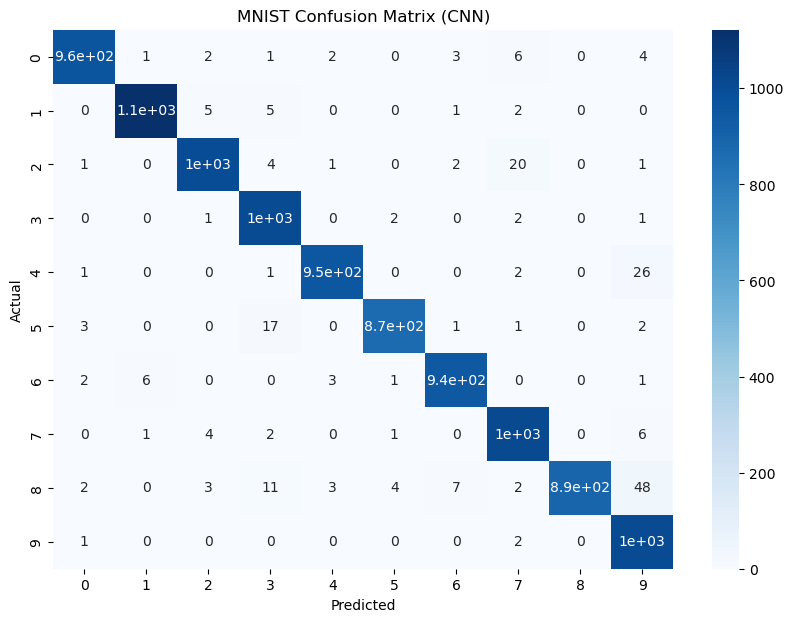

In [7]:
#Q3

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets,transforms
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

batch_size=64
learning_rate=0.001
epochs=5
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform=transforms.ToTensor()

train_dataset=datasets.MNIST(root="./data",train=True,transform=transform,download=True)

test_dataset=datasets.MNIST(root='./data',train=False, transform=transform,download=True)

train_loader=DataLoader(train_dataset,batch_size=batch_size,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=batch_size,shuffle=False)

class CNNClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net=nn.Sequential(nn.Conv2d(1,64,kernel_size=3),
                               nn.ReLU(),
                               nn.MaxPool2d((2,2),stride=2),
                               nn.Conv2d(64,128,kernel_size=3),
                               nn.ReLU(),
                               nn.MaxPool2d((2,2),stride=2),
                               nn.Conv2d(128,64,kernel_size=3),
                               nn.ReLU(),
                               nn.MaxPool2d((2,2),stride=2)
                               )
        self.classification_head=nn.Sequential(nn.Linear(64,20,bias=True),
                                               nn.ReLU(),
                                               nn.Linear(20,10,bias=True))
    
    def forward(self,x):
        features=self.net(x)
        return self.classification_head(features.view(features.size(0),-1))
    
model=CNNClassifier().to(device)
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(),lr=learning_rate)

total_params=sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Total Trainable Parameters: ",total_params)

model.train()
for epoch in range(epochs):
    tot_loss=0.0
    for imgs,labels in train_loader:
        imgs,labels=imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs=model(imgs)
        loss=criterion(outputs,labels)
        loss.backward()
        optimizer.step()

        tot_loss+=loss.item()
    
    print(f"Epoch: {epoch+1}, Loss: {tot_loss/len(train_loader):.4f}")

model.eval()
all_preds=[]
all_labels=[]

with torch.no_grad():
    for img,labels in test_loader:
        img=img.to(device)
        outputs=model(img)
        _,preds=torch.max(outputs,1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm=confusion_matrix(all_labels,all_preds)

plt.figure(figsize=(10,7))
sns.heatmap(cm,annot=True,cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("MNIST Confusion Matrix (CNN)")
plt.show()

Q3 Parameters: 149798
Q3 Accuracy: 98.28
Q4 Parameters: 9974
Q4 Accuracy: 97.32
Parameter Reduction (%): 93.34170015621036


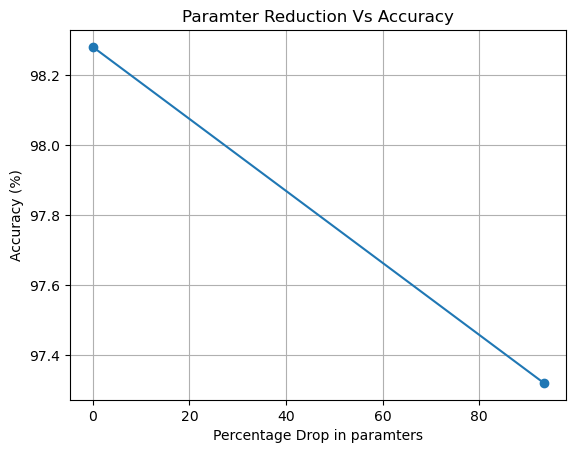

In [ ]:
#Q4

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets,transforms
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

batch_size=64
learning_rate=0.001
epochs=5
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform=transforms.ToTensor()

train_dataset=datasets.MNIST(root='./data',train=True,transform=transform,download=True)

test_dataset=datasets.MNIST(root='./data',train=False,transform=transform,download=True)

train_loader=DataLoader(train_dataset,batch_size=batch_size,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=batch_size,shuffle=False)

class CNNClassifier_Reduced(nn.Module):
    def __init__(self):
        super().__init__()
        self.net=nn.Sequential(nn.Conv2d(1,16,3),
                               nn.ReLU(),
                               nn.MaxPool2d(2,2),
                               
                               nn.Conv2d(16,32,3),
                               nn.ReLU(),
                               nn.MaxPool2d(2,2),
                               
                               nn.Conv2d(32,16,3),
                               nn.ReLU(),
                               nn.MaxPool2d(2,2))
        self.classification_head=nn.Sequential(
            nn.Linear(16,20),
            nn.ReLU(),
            nn.Linear(20,10)
        )
    def forward(self,x):
        features=self.net(x)
        return self.classification_head(features.view(features.size(0),-1))

def train_test(model):
    model=model.to(device)
    criterion=nn.CrossEntropyLoss()
    optimizer=optim.Adam(model.parameters(),lr=learning_rate)

    total_params=sum(p.numel() for p in model.parameters() if p.requires_grad)

    model.train()
    for epoch in range(epochs):
        tot_loss=0.0
        for imgs,labels in train_loader:
            imgs,labels=imgs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs=model(imgs)
            loss=criterion(outputs,labels)
            loss.backward()
            optimizer.step()

            tot_loss+=loss.item()
        
    model.eval()

    correct=0
    total=0
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs,labels=imgs.to(device), labels.to(device)
            outputs=model(imgs)
            _,preds=torch.max(outputs,1)
            correct+=(preds==labels).sum().item()
            total+=labels.size(0)

    accuracy=100*(correct/total)

    return accuracy,total_params

acc_q3,params_q3=train_test(CNNClassifier())
acc_q4,params_q4=train_test(CNNClassifier_Reduced())

param_drop=((params_q3-params_q4)/params_q3)*100

print("Q3 Parameters:", params_q3)
print("Q3 Accuracy:", acc_q3)

print("Q4 Parameters:", params_q4)
print("Q4 Accuracy:", acc_q4)

print("Parameter Reduction (%):", param_drop)

x=[0,param_drop]
y=[acc_q3,acc_q4]

plt.plot(x,y,marker='o')
plt.xlabel("Percentage Drop in paramters")
plt.ylabel("Accuracy %")
plt.title("Paramter Reduction Vs Accuracy")
plt.grid(True)
plt.show()


## Additional

torch.Size([1, 28, 28])
Total Parameters:  149798
Epoch:  1/5, Loss: 0.6412177726189295
Epoch:  2/5, Loss: 0.42770063926776253
Epoch:  3/5, Loss: 0.3612761387030284
Epoch:  4/5, Loss: 0.3226644979953766
Epoch:  5/5, Loss: 0.29203004777729513


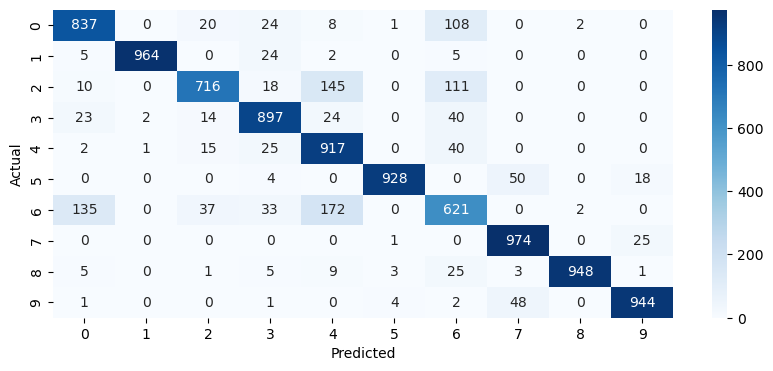

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix
import seaborn as sns

batch_size=32
learning_rate=0.001
epochs=5
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform=transforms.ToTensor()

train_data=datasets.FashionMNIST(root="./data", train=True, transform=transform, download=True)
test_data=datasets.FashionMNIST(root="./data", train=False,transform=transform, download=True)

img, label = train_data[0]
print(img.shape)

train_loader=DataLoader(train_data,batch_size=batch_size, shuffle=True)
test_loader=DataLoader(test_data,batch_size=batch_size,shuffle=False)

class CNNClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net=nn.Sequential(nn.Conv2d(1,64,kernel_size=3),
                               nn.ReLU(),
                               nn.MaxPool2d((2,2),stride=2),

                               nn.Conv2d(64,128,kernel_size=3),
                               nn.ReLU(),
                               nn.MaxPool2d((2,2),stride=2),

                               nn.Conv2d(128,64,kernel_size=3),
                               nn.ReLU(),
                               nn.MaxPool2d((2,2),stride=2))
        self.fc=nn.Sequential(nn.Linear(64,20,bias=True),
                              nn.ReLU(),
                              nn.Linear(20,10,bias=True))
    def forward(self,x):
        features=self.net(x)
        return self.fc(features.view(features.size(0),-1))
    
model=CNNClassifier().to(device)
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(), lr=learning_rate)

total_params=sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Total Parameters: ", total_params)

model.train()
for epoch in range(epochs):
    total_loss=0.0
    for imgs, labels in train_loader:
        images,labels=imgs.to(device),labels.to(device)
        outputs=model(images)
        loss=criterion(outputs,labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss+=loss.item()
    print(f"Epoch:  {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader)}")

model.eval()
all_preds, all_labels=[], []
with torch.no_grad():
    for images, labels in test_loader:
        images,labels=images.to(device), labels.to(device)
        outputs=model(images)
        _,preds=torch.max(outputs,1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm=confusion_matrix(all_labels,all_preds)
plt.figure(figsize=(10,4))
sns.heatmap(cm, annot=True, fmt='d',cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()